# 07 · Where the land went, and is cassava even the right lever?

Notebooks 05 and 06 left two questions open that the GROW rubric explicitly asks for, and that
`CONTEXT.md` flagged as the deck's weakest links:

1. **"Test what's driving them."** Every Indonesian food staple lost area 2010→2024 (nb 03/04). We showed
   *that* it happened and that yield partly cushioned it — but never tested **where the land went.**
   That was deferred to SUSTAIN's land-cover data. It turns out QCL can answer most of it.
2. **"Spot a crop worth investigating."** The deck assumes **cassava**. That assumption was inherited from
   the MOCAF research, never tested against Indonesia's other domestic starch crops. If cassava is the
   right lever, we should be able to show the alternatives are worse.

And it surfaces a third mechanism nobody has connected yet: **maize**. The deck notes feed-wheat imports
doubled because corn got expensive. GROW data shows *why* corn got expensive.

Sections:
1. Setup
2. Where did the land go? — the oil palm reallocation
3. Is cassava the right substitute? — testing the alternatives
4. The maize channel — a second, independent route into wheat dependence
5. Producer- and policymaker-level actions, ranked and sized
6. Findings

## 1. Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from src.load import load_indonesia
from src.clean import drop_item_aggregates
from src import viz

ROOT_TABLES = Path('..') / 'outputs' / 'tables'
ROOT_TABLES.mkdir(parents=True, exist_ok=True)

qcl = load_indonesia('QCL')
LATEST, BASE = qcl['year'].max(), qcl['year'].min()

def by_item(item):
    """Production / Area harvested / Yield pivot for one item, indexed by year."""
    return qcl[qcl['Item'] == item].pivot_table(index='year', columns='Element', values='value')

print(f'Indonesia QCL {BASE}\u2013{LATEST}')

[cache] QCL_indonesia_2010_2024.parquet


Indonesia QCL 2010–2024


## 2. Where did the land go?

The claim so far has been "staples are losing area." The obvious follow-up — *is Indonesia running out of
farmland, or reallocating it?* — is answerable here, because QCL carries **area harvested for every crop**.
If total cropped area shrank, it's a land-availability problem. If total area grew while staples shrank,
it's a **choice**, and choices respond to policy.

In [2]:
area = drop_item_aggregates(qcl[qcl['Element'] == 'Area harvested'])
apv = area.pivot_table(index='Item', columns='year', values='value')
chg = pd.DataFrame({BASE: apv[BASE], LATEST: apv[LATEST]}).dropna()
chg['change_ha'] = chg[LATEST] - chg[BASE]
chg['change_%'] = 100 * (chg[LATEST] / chg[BASE] - 1)

print(f'TOTAL cropped area, all crops: {chg[BASE].sum()/1e6:,.2f}M ha ({BASE}) -> '
      f'{chg[LATEST].sum()/1e6:,.2f}M ha ({LATEST})  '
      f'= {chg["change_ha"].sum()/1e6:+,.2f}M ha\n')
print('-> Indonesia is NOT running out of cropland. It planted 3.7M ha MORE in 2024 than in 2010.')
print('   The staple decline is a reallocation, not a shortage.\n')
print('Biggest area GAINS (ha):')
print(chg.sort_values('change_ha', ascending=False).head(8)[['change_ha', 'change_%']].round(0).to_string())
print('\nBiggest area LOSSES (ha):')
print(chg.sort_values('change_ha').head(8)[['change_ha', 'change_%']].round(0).to_string())

TOTAL cropped area, all crops: 34.54M ha (2010) -> 38.28M ha (2024)  = +3.75M ha

-> Indonesia is NOT running out of cropland. It planted 3.7M ha MORE in 2024 than in 2010.
   The staple decline is a reallocation, not a shortage.

Biggest area GAINS (ha):
                                                              change_ha  change_%
Item                                                                             
Oil palm fruit                                                8540000.0     148.0
Cloves (whole stems), raw                                      255195.0      80.0
Nutmeg, mace, cardamoms, raw                                   166726.0     142.0
Mangoes, guavas and mangosteens                                158070.0     120.0
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)    92952.0      39.0
Sugar cane                                                      88286.0      20.0
Onions and shallots, dry (excluding dehydrated)                 79162.0      72.0
Banana

In [3]:
STAPLES = ['Rice', 'Maize (corn)', 'Cassava, fresh', 'Soya beans',
           'Groundnuts, excluding shelled', 'Sweet potatoes']
op = by_item('Oil palm fruit')['Area harvested']
cas = by_item('Cassava, fresh')['Area harvested']

op_gain     = op.loc[LATEST] - op.loc[BASE]
cas_loss    = cas.loc[BASE] - cas.loc[LATEST]
staple_loss = sum(by_item(i)['Area harvested'].loc[BASE] -
                  by_item(i)['Area harvested'].loc[LATEST] for i in STAPLES)

print(f'Oil palm area:  {op.loc[BASE]/1e6:.2f}M -> {op.loc[LATEST]/1e6:.2f}M ha '
      f'({op_gain/1e6:+.2f}M ha, {100*(op.loc[LATEST]/op.loc[BASE]-1):+.0f}%)')
print(f'6 food staples: {-staple_loss/1e6:+.2f}M ha over the same period')
print(f'\nOil palm gained {op_gain/staple_loss:.1f}x what the six staples lost, combined.')
print(f'Oil palm gained {op_gain/cas_loss:.1f}x cassava\'s ENTIRE area loss ({cas_loss:,.0f} ha).')
print(f'\n=> Restoring cassava to its {BASE} footprint needs {100*cas_loss/op_gain:.1f}% of the oil palm')
print(f'   land ADDED since {BASE}. Framed that way it is a rounding error, not a land crisis.')
print('\nCAVEAT \u2014 this is coincidence of areas, not parcel-level conversion. QCL cannot show that a')
print('specific cassava field became an oil palm block; only that total area grew while staples shrank.')
print('That is enough to rule out "no land available", which is the excuse the recommendation has to')
print('clear. Proving the conversion pathway needs land-cover data (SUSTAIN track).')

Oil palm area:  5.78M -> 14.32M ha (+8.54M ha, +148%)
6 food staples: -5.04M ha over the same period

Oil palm gained 1.7x what the six staples lost, combined.
Oil palm gained 13.6x cassava's ENTIRE area loss (629,597 ha).

=> Restoring cassava to its 2010 footprint needs 7.4% of the oil palm
   land ADDED since 2010. Framed that way it is a rounding error, not a land crisis.

CAVEAT — this is coincidence of areas, not parcel-level conversion. QCL cannot show that a
specific cassava field became an oil palm block; only that total area grew while staples shrank.
That is enough to rule out "no land available", which is the excuse the recommendation has to
clear. Proving the conversion pathway needs land-cover data (SUSTAIN track).


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_land_reallocation.png


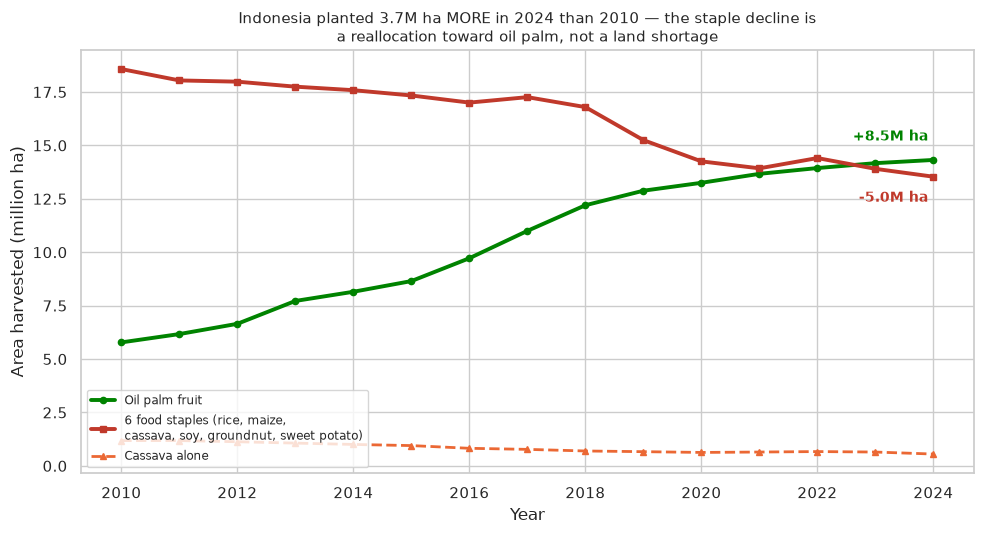

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(op.index, op / 1e6, color='#008300', lw=2.8, marker='o', ms=4.5, label='Oil palm fruit')
staple_tot = sum(by_item(i)['Area harvested'] for i in STAPLES)
ax.plot(staple_tot.index, staple_tot / 1e6, color='#c0392b', lw=2.8, marker='s', ms=4.5,
        label='6 food staples (rice, maize,\ncassava, soy, groundnut, sweet potato)')
ax.plot(cas.index, cas / 1e6, color='#eb6834', lw=2, ls='--', marker='^', ms=4, label='Cassava alone')

# The two series converge at the right edge, so offset the labels in opposite directions.
ax.annotate(f'{op_gain/1e6:+.1f}M ha', xy=(LATEST, op.loc[LATEST] / 1e6),
            xytext=(-4, 14), textcoords='offset points', fontsize=10,
            color='#008300', fontweight='bold', ha='right')
ax.annotate(f'{-staple_loss/1e6:+.1f}M ha', xy=(LATEST, staple_tot.loc[LATEST] / 1e6),
            xytext=(-4, -18), textcoords='offset points', fontsize=10,
            color='#c0392b', fontweight='bold', ha='right')

ax.set_ylabel('Area harvested (million ha)')
ax.set_xlabel('Year')
ax.set_title('Indonesia planted 3.7M ha MORE in 2024 than 2010 — the staple decline is\n'
             'a reallocation toward oil palm, not a land shortage', fontsize=11)
ax.legend(fontsize=8.5, loc='lower left')
fig.tight_layout()
viz.save(fig, 'idn_land_reallocation')
plt.show()

### External corroboration (task E2) — including one source that disagrees

Everything above is derived **inside** QCL: total area up, staples down, oil palm up. That is area
arithmetic, so it is worth asking whether anyone outside this dataset sees the same thing. Two official
sources were checked. They do not fully agree with each other, and that is reported rather than resolved.

**1. Structural conversion — on point (USDA GAIN ID2026-0010, p. 20).** Indonesia's Minister of Agrarian
Affairs and Spatial Planning / Head of the National Land Agency (**ATR/BPN**), reiterating a BPS report,
attributes ongoing loss of paddy area to **conversion to non-agricultural uses — housing, industrial
area and infrastructure development** — and notes this is concentrated on **Java**, where 60% of the
population lives. This is the one external statement that speaks to the same *structural* mechanism
§2 derives internally: cropland leaving staples for other uses, not disappearing.
*No hectares-per-year figure is quoted here* — see the access gap below.

**2. Crop-level land substitution — direct support (GAIN, pp. 1, 4, 13).** GAIN forecasts paddy harvested
area to **decline in 2025/26 and 2026/27** as farmers switch from paddy to corn under a potential moderate
El Niño, because corn needs less water — and, critically for §2's logic, *"since most corn and paddy are
grown in the same fields."* That is external, official confirmation that Indonesian cropland is
**substitutable between crops at field level**, which is the premise the reallocation reading rests on.
(It also ties the El Niño angle to land use, not just to supplier risk in nb 06.)

**3. A source that does NOT corroborate (FAO GIEWS Indonesia Country Brief, ref. 29-January-2026).**
GIEWS reports the opposite sign for the near term: the 2026 First paddy crop's *"area planted is estimated
to be above the five-year average, supported by favourable price prospects and official incentives"*, and
2025 paddy production of 59 Mt, ~9% above average, *"reflecting a price-driven expansion in the area
planted."* Two honest reconciliations, neither of which we can settle here:
- **Different metric.** GIEWS reports *area planted*; GAIN forecasts *area harvested*. Drought raises
  abandonment between the two, so planted-up and harvested-down are compatible.
- **Different window.** Both speak to the **2025–2027 margin**; this notebook's finding is the
  **2010–2024 structural** trend. Neither source confirms *or* refutes the 15-year reallocation.

So: treat GAIN as corroboration of the *mechanism*, and treat the near-term direction as **contested**.
Do not put "official sources confirm paddy area is falling" on a slide — one of them says the opposite.

**Access-blocked gap (documented, not silently dropped).** The primary series that would settle the
magnitude — Kementan's *Statistik Lahan Pertanian* on `satudata.pertanian.go.id` — is behind a
**Cloudflare block (HTTP 403** on both the PDF and the portal root, with and without a browser
user-agent); the main `pertanian.go.id` domain soft-404s the same path. The ATR/BPN series was likewise
not obtained at origin. The conversion mechanism is therefore corroborated **only at second hand**, via
GAIN quoting ATR/BPN quoting BPS. See `CONTEXT.md` → Enrichment tasks.

**The parcel-level caveat still stands, unchanged.** None of this is field-level conversion evidence.
QCL shows national area coincidence; GAIN adds that paddy and corn share fields and that conversion to
built-up uses is happening on Java. Proving that a *specific* cassava field became oil palm still needs
land-cover data (SUSTAIN).

> *Provenance:* both sources are external, not FAOSTAT and not this repo's data. GAIN ID2026-0010 is a
> USDA FAS publication (local copy in `OtherDetails/`); GIEWS is at
> `fao.org/giews/countrybrief/country.jsp?code=IDN`. The ATR/BPN land figure inside GAIN is a
> **secondary citation** (GAIN → ATR/BPN → BPS) and must be labelled as such wherever it is used.

## 3. Is cassava actually the right substitute?

The deck's whole solution rests on cassava. That came from the MOCAF literature, not from a comparison.
A GROW-track answer has to check the bench: what **other** domestic starch crops could feed a wheat-flour
substitute, and are any of them in better shape?

In [5]:
# Every plausible domestic starch / flour-capable crop. Absent items are reported, not skipped —
# their absence from FAOSTAT is itself a finding (see the sago note below).
CANDIDATES = ['Cassava, fresh', 'Rice', 'Maize (corn)', 'Sweet potatoes', 'Potatoes',
              'Taro', 'Yams', 'Sorghum', 'Millet', 'Sago', 'Breadfruit', 'Plantains and cooking bananas']

rows, absent = [], []
for it in CANDIDATES:
    p = by_item(it)
    if p.empty or 'Production' not in p:
        absent.append(it); continue
    rows.append({'crop': it,
                 f'prod_Mt_{LATEST}': p['Production'].loc[LATEST] / 1e6,
                 'prod_%chg': 100 * (p['Production'].loc[LATEST] / p['Production'].loc[BASE] - 1),
                 'area_kha': p['Area harvested'].loc[LATEST] / 1e3,
                 'area_%chg': 100 * (p['Area harvested'].loc[LATEST] / p['Area harvested'].loc[BASE] - 1),
                 'yield_t_ha': p['Yield'].loc[LATEST] / 1000})
cand = pd.DataFrame(rows).set_index('crop').sort_values(f'prod_Mt_{LATEST}', ascending=False)
print(cand.round(1).to_string())
print(f'\nNot in Indonesia\'s QCL at all: {absent}')
print('\nNote: **sago** is a genuine regional staple (Papua, Maluku) and a real flour crop, but FAOSTAT')
print('carries no Indonesian sago series \u2014 so this repo cannot size it. That is a data gap, not a zero.')

                prod_Mt_2024  prod_%chg  area_kha  area_%chg  yield_t_ha
crop                                                                    
Rice                    53.1      -10.4   10046.1      -14.8         5.3
Cassava, fresh          15.6      -34.7     553.4      -53.2        28.2
Maize (corn)            15.1      -17.4    2548.7      -38.3         5.9
Sweet potatoes           1.5      -27.9      68.6      -62.1        21.6
Potatoes                 1.3       19.8      67.5        1.4        18.8

Not in Indonesia's QCL at all: ['Taro', 'Yams', 'Sorghum', 'Millet', 'Sago', 'Breadfruit', 'Plantains and cooking bananas']

Note: **sago** is a genuine regional staple (Papua, Maluku) and a real flour crop, but FAOSTAT
carries no Indonesian sago series — so this repo cannot size it. That is a data gap, not a zero.


In [6]:
cas_prod = by_item('Cassava, fresh')['Production'].loc[LATEST] / 1e6
print('Verdict on the bench, by elimination:\n')
print(f'  Rice        \u2014 biggest crop by far, but it IS the staple wheat competes with. Diverting rice')
print(f'                to flour substitutes one import dependence for a domestic shortfall. Not a lever.')
print(f'  Maize       \u2014 15.1 Mt, but already the binding constraint in the FEED market (see \u00a74), and')
print(f'                its own area fell 38%. Diverting maize to flour makes the wheat problem worse.')
sp = cand.loc['Sweet potatoes']
print(f'  Sweet potato\u2014 {sp[f"prod_Mt_{LATEST}"]:.2f} Mt = {100*sp[f"prod_Mt_{LATEST}"]/cas_prod:.0f}% of cassava\'s volume, and '
      f'falling faster in area\n                ({sp["area_%chg"]:+.0f}% vs cassava\'s -53%). Too small to matter.')
po = cand.loc['Potatoes']
print(f'  Potato      \u2014 the ONLY starch crop growing ({po["prod_%chg"]:+.0f}% production), but at '
      f'{po[f"prod_Mt_{LATEST}"]:.2f} Mt it is\n                {100*po[f"prod_Mt_{LATEST}"]/cas_prod:.0f}% of cassava, is a fresh-market crop, and does not '
      f'ferment to a wheat-\n                substitute flour. Not a candidate at scale.')
print(f'  Sago        \u2014 potentially real, UNMEASURED in FAOSTAT. Flagged, not dismissed.')
print(f'\n  Cassava     \u2014 {cas_prod:.1f} Mt, ~10x the next non-competing candidate, already has a proven')
print(f'                processing route (MOCAF) and a near-frontier yield (nb 05). CONFIRMED as the lever.')
print('\n-> The deck\'s choice of cassava survives the test \u2014 but for a sharper reason than "Indonesia grows')
print('   a lot of cassava": every alternative is either smaller, shrinking faster, or already spoken for.')
print('   Cassava is the lever by elimination, which is a stronger claim than assumption.')

Verdict on the bench, by elimination:

  Rice        — biggest crop by far, but it IS the staple wheat competes with. Diverting rice
                to flour substitutes one import dependence for a domestic shortfall. Not a lever.
  Maize       — 15.1 Mt, but already the binding constraint in the FEED market (see §4), and
                its own area fell 38%. Diverting maize to flour makes the wheat problem worse.
  Sweet potato— 1.48 Mt = 9% of cassava's volume, and falling faster in area
                (-62% vs cassava's -53%). Too small to matter.
  Potato      — the ONLY starch crop growing (+20% production), but at 1.27 Mt it is
                8% of cassava, is a fresh-market crop, and does not ferment to a wheat-
                substitute flour. Not a candidate at scale.
  Sago        — potentially real, UNMEASURED in FAOSTAT. Flagged, not dismissed.

  Cassava     — 15.6 Mt, ~10x the next non-competing candidate, already has a proven
                processing route (MOCAF) 

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_substitute_candidates.png


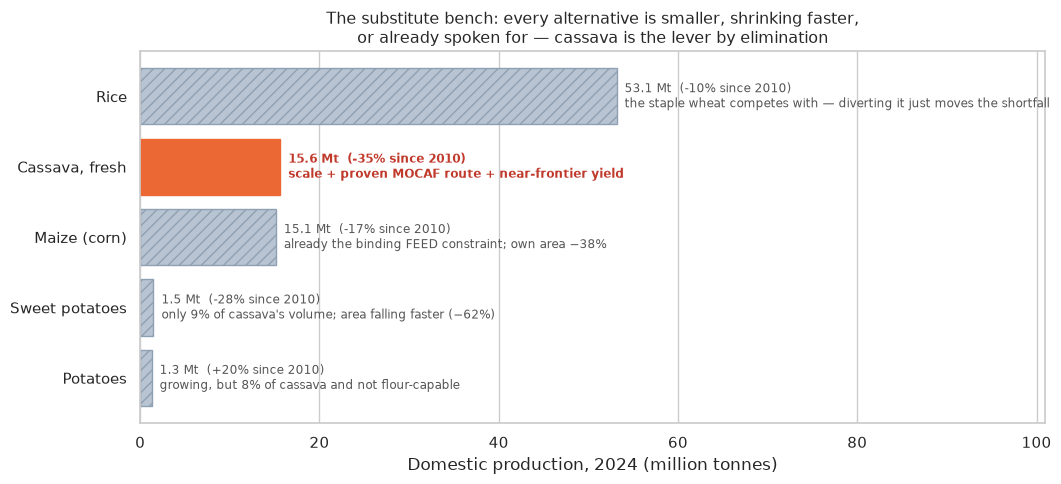

In [7]:
# A 4-point scatter wastes the space; the elimination story is really about SCALE plus a
# disqualifying reason per crop. One labelled bar chart carries both.
DISQUALIFIER = {
    'Rice':           'the staple wheat competes with \u2014 diverting it just moves the shortfall',
    'Maize (corn)':   'already the binding FEED constraint; own area \u221238%',
    'Sweet potatoes': 'only 9% of cassava\'s volume; area falling faster (\u221262%)',
    'Potatoes':       'growing, but 8% of cassava and not flour-capable',
    'Cassava, fresh': 'scale + proven MOCAF route + near-frontier yield',
}
order = cand.sort_values(f'prod_Mt_{LATEST}')
fig, ax = plt.subplots(figsize=(11, 5))
for i, (crop, r) in enumerate(order.iterrows()):
    is_cas = crop == 'Cassava, fresh'
    ax.barh(i, r[f'prod_Mt_{LATEST}'], color='#eb6834' if is_cas else '#b8c4d1',
            hatch='' if is_cas else '///', edgecolor='#8fa0b3' if not is_cas else '#eb6834')
    ax.text(r[f'prod_Mt_{LATEST}'] + 0.9, i,
            f"{r[f'prod_Mt_{LATEST}']:.1f} Mt  ({r['prod_%chg']:+.0f}% since {BASE})\n"
            f"{DISQUALIFIER[crop]}",
            va='center', fontsize=8.3,
            color='#c0392b' if is_cas else '#555',
            fontweight='bold' if is_cas else 'normal')

ax.set_yticks(range(len(order)), order.index)
ax.set_xlim(0, order[f'prod_Mt_{LATEST}'].max() * 1.9)
ax.set_xlabel(f'Domestic production, {LATEST} (million tonnes)')
ax.set_title('The substitute bench: every alternative is smaller, shrinking faster,\n'
             'or already spoken for \u2014 cassava is the lever by elimination', fontsize=11.5)
ax.grid(axis='y', visible=False)
fig.tight_layout()
viz.save(fig, 'idn_substitute_candidates')
plt.show()

## 4. The maize channel — a second route into wheat dependence

The deck reports (GAIN) that **feed wheat nearly doubled, 1.1 → 2.1 MMT**, because millers substituted
wheat for expensive corn — and that a 42% import surge in 2015–16 followed an El Niño hit to domestic corn.
It treats that as a demand-side quirk. GROW data shows it is a **production** story, and it means Indonesia
has *two* independent paths into wheat imports, not one.

In [8]:
mz = by_item('Maize (corn)')
peak_yr = int(mz['Production'].idxmax())
print(pd.DataFrame({'production_Mt': mz['Production'] / 1e6,
                    'area_kha': mz['Area harvested'] / 1e3,
                    'yield_kg_ha': mz['Yield']}).round(1).to_string())
print(f'\nMaize area:       {mz["Area harvested"].loc[BASE]/1e6:.2f}M -> '
      f'{mz["Area harvested"].loc[LATEST]/1e6:.2f}M ha '
      f'({100*(mz["Area harvested"].loc[LATEST]/mz["Area harvested"].loc[BASE]-1):+.0f}%)')
print(f'Maize production: peak {mz["Production"].loc[peak_yr]/1e6:.1f} Mt ({peak_yr}) -> '
      f'{mz["Production"].loc[LATEST]/1e6:.1f} Mt ({LATEST}) '
      f'({100*(mz["Production"].loc[LATEST]/mz["Production"].loc[peak_yr]-1):+.0f}% from peak)')
print(f'Maize yield:      {100*(mz["Yield"].loc[LATEST]/mz["Yield"].loc[BASE]-1):+.0f}% '
      f'\u2014 same pattern as every other staple: intensifying on shrinking land.')
print('\nThe chain, entirely inside GROW data plus GAIN\'s feed number:')
print(f'  maize area -38% and production -{abs(100*(mz["Production"].loc[LATEST]/mz["Production"].loc[peak_yr]-1)):.0f}% off peak')
print('     -> domestic corn tighter and dearer')
print('     -> feed millers substitute WHEAT for corn (GAIN: 1.1 -> 2.1 MMT feed wheat)')
print('     -> wheat imports rise for a reason that has nothing to do with bread.')
print('\nWhy this matters for the recommendation: MOCAF addresses the FOOD-wheat stream only')
print('(nb 05 sized it against the 9.8 MMT food demand). It does nothing for the ~2.1 MMT feed')
print('stream. Maize land retention is a SEPARATE lever against a SEPARATE part of the import bill.')

      production_Mt  area_kha  yield_kg_ha
year                                      
2010           18.3    4131.7       4435.9
2011           17.6    3864.7       4565.2
2012           19.4    3957.6       4898.7
2013           18.5    3821.5       4844.1
2014           19.0    3837.0       4954.0
2015           19.6    3787.4       5178.4
2016           23.6    4444.4       5305.2
2017           25.2    4750.0       5297.7
2018           18.8    3550.0       5307.0
2019           19.6    3198.3       6143.9
2020           12.9    2337.9       5530.2
2021           13.4    2328.1       5762.3
2022           16.5    2764.4       5978.7
2023           14.8    2476.1       5966.8
2024           15.1    2548.7       5940.0

Maize area:       4.13M -> 2.55M ha (-38%)
Maize production: peak 25.2 Mt (2017) -> 15.1 Mt (2024) (-40% from peak)
Maize yield:      +34% — same pattern as every other staple: intensifying on shrinking land.

The chain, entirely inside GROW data plus GAIN's feed numb

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_maize_channel.png


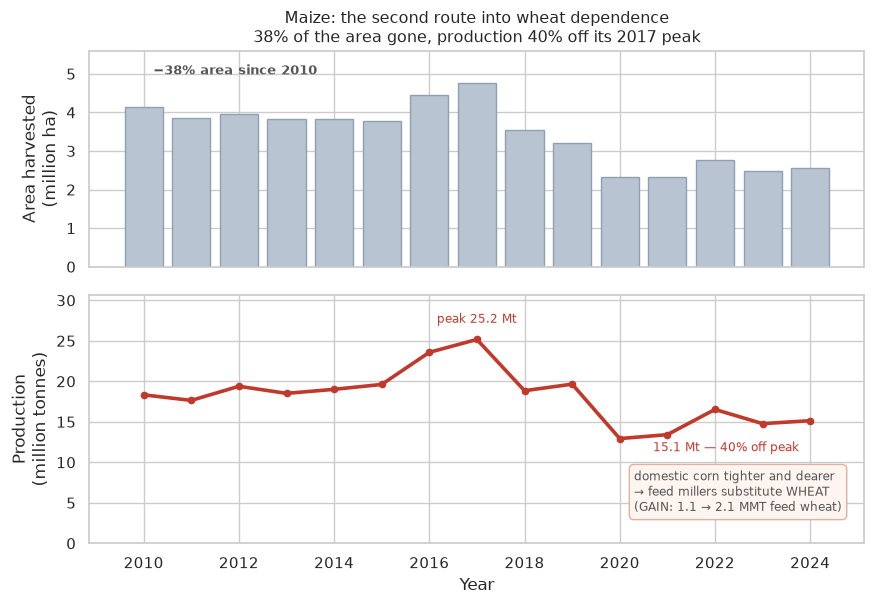

In [9]:
# Two stacked panels rather than a twin axis: a dual axis here would need a non-zero
# production scale to fit, which visually exaggerates the swing next to zero-based area bars.
fig, (axa, axp) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1.15], 'hspace': 0.12})

axa.bar(mz.index, mz['Area harvested'] / 1e6, color='#b8c4d1', edgecolor='#8fa0b3')
axa.set_ylabel('Area harvested\n(million ha)')
axa.set_ylim(0, mz['Area harvested'].max() / 1e6 * 1.18)
axa.annotate(f"\u2212{abs(100*(mz['Area harvested'].loc[LATEST]/mz['Area harvested'].loc[BASE]-1)):.0f}% "
             f"area since {BASE}", xy=(BASE + 0.2, mz['Area harvested'].max() / 1e6 * 1.05),
             fontsize=9.5, color='#555', fontweight='bold')

axp.plot(mz.index, mz['Production'] / 1e6, color='#c0392b', lw=2.6, marker='o', ms=4.5)
axp.set_ylabel('Production\n(million tonnes)')
axp.set_ylim(0, mz['Production'].max() / 1e6 * 1.22)
axp.set_xlabel('Year')
axp.annotate(f"peak {mz['Production'].loc[peak_yr]/1e6:.1f} Mt",
             xy=(peak_yr, mz['Production'].loc[peak_yr] / 1e6),
             xytext=(0, 12), textcoords='offset points', fontsize=8.5, ha='center', color='#c0392b')
axp.annotate(f"{mz['Production'].loc[LATEST]/1e6:.1f} Mt \u2014 "
             f"{abs(100*(mz['Production'].loc[LATEST]/mz['Production'].loc[peak_yr]-1)):.0f}% off peak",
             xy=(LATEST, mz['Production'].loc[LATEST] / 1e6),
             xytext=(-8, -22), textcoords='offset points', fontsize=8.5, ha='right', color='#c0392b')
axp.annotate('domestic corn tighter and dearer\n\u2192 feed millers substitute WHEAT\n'
             '(GAIN: 1.1 \u2192 2.1 MMT feed wheat)',
             xy=(2020.3, 4.0), fontsize=8.5, color='#555',
             bbox=dict(boxstyle='round,pad=0.4', fc='#fff5f0', ec='#e0b0a0'))

axa.set_title('Maize: the second route into wheat dependence\n'
              '38% of the area gone, production 40% off its 2017 peak', fontsize=11.5)
viz.save(fig, 'idn_maize_channel')
plt.show()

## 5. Actions, ranked and sized

The rubric asks for actions **producers or policymakers** could take on the production findings. Everything
below is sized from this repo's own numbers, so each line carries a magnitude rather than a sentiment.
Levers are ranked by tonnes of wheat-equivalent relief per unit of difficulty.

In [10]:
FRONTIER_KG_HA = 35574.0     # India, peer-scale frontier (nb 05 §5)
cas_p = by_item('Cassava, fresh')
idn_y, cur_area = cas_p['Yield'].loc[LATEST], cas_p['Area harvested'].loc[LATEST]
MOCAF = {'community sun-dried (20%)': 0.20, 'lab tape-yeast (34.6%)': 0.346}
WHEAT_FOOD_MMT = 9.8

gap_mt   = (FRONTIER_KG_HA - idn_y) * cur_area / 1e9
retain_mt = cas_loss * idn_y / 1e9                       # cassava area lost since BASE, at today's yield
proc_gain = (0.346 / 0.20 - 1)                           # relief from upgrading conversion yield alone

rows = [
    {'lever': 'A. Processing-yield upgrade (20% -> 34.6% MOCAF)',
     'actor': 'processors / producers',
     'cassava_Mt_equivalent': None,
     'wheat_flour_blend_pts': 100 * (by_item('Cassava, fresh')['Production'].loc[LATEST]/1e6) * (0.346-0.20) / WHEAT_FOOD_MMT,
     'note': f'no new land or cassava; cuts cassava needed per tonne of wheat by {100*(1-0.20/0.346):.0f}%'},
    {'lever': 'B. Cassava land retention (stop the -53% slide)',
     'actor': 'policymakers',
     'cassava_Mt_equivalent': retain_mt,
     'wheat_flour_blend_pts': 100 * retain_mt * 0.346 / WHEAT_FOOD_MMT,
     'note': f'needs {100*cas_loss/op_gain:.1f}% of the oil palm land added since {BASE}'},
    {'lever': 'C. Close the cassava yield gap to India',
     'actor': 'producers + extension',
     'cassava_Mt_equivalent': gap_mt,
     'wheat_flour_blend_pts': 100 * gap_mt * 0.346 / WHEAT_FOOD_MMT,
     'note': 'already #2 of 40 peers — hardest marginal gains, but land-neutral'},
    {'lever': 'D. Maize land retention (feed-wheat stream)',
     'actor': 'policymakers',
     'cassava_Mt_equivalent': None,
     'wheat_flour_blend_pts': None,
     'note': 'targets the ~2.1 MMT FEED wheat stream that MOCAF cannot touch'},
]
act = pd.DataFrame(rows).set_index('lever')
print(act.to_string())
print('\nNOTE on the blend-points column: lever A is measured on TODAY\'s crop (the same cassava,')
print('converted better), while B and C are NEW cassava at 34.6%. They are not additive as printed \u2014')
print('A multiplies whatever volume B and C deliver, which is why it is ranked first.')
out = ROOT_TABLES / 'grow_action_levers.csv'
act.to_csv(out); print(f'\ntable -> {out}')

print(f'\nSized together (upper bound, all three cassava levers, at 34.6% conversion):')
combined = retain_mt + gap_mt
print(f'  land retention + yield gap = {combined:,.2f} Mt extra fresh cassava')
print(f'  -> {combined*0.346:,.2f} Mt MOCAF = a {100*combined*0.346/WHEAT_FOOD_MMT:,.0f}% wheat-flour blend '
      f'from NEW cassava alone,')
print(f'     without diverting one tonne of today\'s crop.')
print(f'\n  Compare: today\'s ENTIRE crop at 20% conversion tops out at a '
      f'{100*(by_item("Cassava, fresh")["Production"].loc[LATEST]/1e6)*0.20/WHEAT_FOOD_MMT:,.0f}% blend ceiling (nb 05 \u00a76).')
print('  So the achievable path runs through retention + processing, not through diverting the crop.')
print('\nREAD THIS AS HEADROOM, NOT A TARGET. A 77% blend is nowhere near realistic \u2014 baking')
print('functionality caps wheat-flour substitution far lower, and the deck\'s own working band is')
print('10\u201320%. The point is that at a 10\u201320% blend the binding constraint is NOT raw cassava')
print('availability: it is processing capacity, conversion yield, and miller/consumer acceptance.')
print('Production is not what limits this solution \u2014 which is itself a GROW finding.')

                                                                   actor  cassava_Mt_equivalent  wheat_flour_blend_pts                                                                   note
lever                                                                                                                                                                                        
A. Processing-yield upgrade (20% -> 34.6% MOCAF)  processors / producers                    NaN              23.276628  no new land or cassava; cuts cassava needed per tonne of wheat by 42%
B. Cassava land retention (stop the -53% slide)             policymakers              17.773712              62.752086                       needs 7.4% of the oil palm land added since 2010
C. Close the cassava yield gap to India            producers + extension               4.064371              14.349717      already #2 of 40 peers — hardest marginal gains, but land-neutral
D. Maize land retention (feed-wheat stream)       

## 6. Findings

### Where the land went — the mechanism the deck was missing
- **Indonesia is not short of cropland.** Total area harvested across all crops **rose 3.75M ha**
  (2010→2024). The staple decline is a **reallocation**, not a shortage — and reallocations respond to
  policy in a way shortages don't.
- **Oil palm took 8.54M ha** (5.78M → 14.32M ha, **+148%**) while six food staples gave up **5.04M ha**.
  Oil palm's gain is **1.7×** the staples' combined loss and **13.6×** cassava's entire area loss.
- **The ask is therefore small.** Restoring cassava to its 2010 footprint needs **7.4% of the oil palm land
  added since 2010** — a rounding error against the expansion, not a land crisis.
- *Honest limit:* this is coincidence of areas, not parcel-level conversion. QCL cannot prove a cassava
  field became an oil palm block. It **can** rule out "there is no land," which is the objection the
  recommendation has to clear. Proving the pathway needs land-cover data (SUSTAIN).

### Cassava survives the test — by elimination, which is a stronger claim than assumption
- **Rice** (53.1 Mt) is the crop wheat competes with; diverting it swaps an import gap for a domestic one.
- **Maize** (15.1 Mt) is already the binding constraint in the feed market and lost 38% of its own area.
- **Sweet potato** (1.48 Mt) is **9% of cassava's volume** and shrinking faster in area (−62% vs −53%).
- **Potato** is the only starch crop *growing* (+19.8%) but is 8% of cassava's volume and doesn't ferment
  to a wheat-substitute flour.
- **Sago** is a genuine regional staple with **no FAOSTAT Indonesian series** — a data gap, not a zero.
  Worth naming in the deck rather than silently omitting.
- **Cassava**: ~10× the next non-competing candidate, a proven processing route, and near-frontier yield.

### Maize is a second, independent route into wheat dependence
- Maize area **−38%** (4.13M → 2.55M ha); production **40% off its 2017 peak** (25.2 → 15.1 Mt).
- Chain: less domestic corn → dearer corn → feed millers substitute wheat (GAIN: **1.1 → 2.1 MMT**).
- **This matters for scoping the solution:** nb 05 sized MOCAF against the **9.8 MMT food** stream. MOCAF
  does nothing for the **~2.1 MMT feed** stream. Maize land retention is a separate lever on a separate
  part of the import bill — and the deck currently has no lever there at all.

### The ranked action set
| # | Lever | Actor | Sized effect |
|---|---|---|---|
| A | Processing yield 20% → 34.6% | Processors | Cuts cassava needed per tonne of wheat by **42%**; no new land or crop |
| B | Cassava land retention | Policymakers | **+17.8 Mt** cassava = **+63 blend points** at 34.6%; needs 7.4% of new oil palm land |
| C | Close yield gap to India | Producers + extension | **+4.06 Mt** = **+14 blend points**, land-neutral, hardest marginal gains |
| D | Maize land retention | Policymakers | Only lever that touches the **~2.1 MMT feed-wheat** stream |

**Retention + yield gap together = +21.8 Mt of new cassava = a ~77% flour-blend *equivalent* from new crop
alone** — which is why the achievable path runs through **retention and processing**, not through diverting
today's harvest (whose ceiling at community-scale conversion is a 32% blend).

> **Read that as headroom, not a target.** A 77% blend is nowhere near realistic — baking functionality caps
> wheat-flour substitution far lower and the working band stays **10–20%**. The point is the *direction* of
> the constraint: at 10–20%, raw cassava availability is **not** what binds. Processing capacity, conversion
> yield, and miller/consumer acceptance are. **Production is not the limiting factor on this solution** —
> which is itself a GROW finding, and the honest thing for a production-track deck to say.

**Ordering for the deck:** A first (cheapest, no land, halves the raw-material requirement), then B (largest
tonnage, and now backed by the oil palm comparison), then C (real but bounded — don't lead with it, Indonesia
is already #2 of 40 peers), then D as the separate feed-side ask.

In [11]:
print('Notebook 07 complete.')
print('  figures -> outputs/figures/idn_land_reallocation.png, idn_substitute_candidates.png,')
print('             idn_maize_channel.png')
print(f'  table   -> {ROOT_TABLES / "grow_action_levers.csv"}')

Notebook 07 complete.
  figures -> outputs/figures/idn_land_reallocation.png, idn_substitute_candidates.png,
             idn_maize_channel.png
  table   -> ../outputs/tables/grow_action_levers.csv
